In [1]:
import subprocess
import sys
import re
import os
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp

from astropy import units as u
import numpy as np
from astropy.constants import G, sigma_sb, k_B

### Planet/Impact param set up

$\Delta S = \frac{\Delta Q}{T}$, where $T$ is approximated as $T_{eq}$ and core heating is ignored

- Core cooling might prolong the inflation?

$E_{imp} = \eta M_{imp} \frac{GM_p}{R_c}$

$S-S_0 = \frac{E_{imp}}{T_{eq}}$

In [2]:
#Input parameters
#Planet

Impact_mass_fraction = 0.02 # <-- Free variable
M_p = 8 * u.Mearth
R_p = 10 * u.Rearth
f_env = 0.2 # Do parameter sweep

#Test param
current_spec_entropy = 6.0 #kB/Baryon

#Star
L = 1 * u.Lsun # Checked

a = 0.3 * u.AU # Checked
#Backend assumptions
eta = 0.5 # Realistic ish value
mmw = 2.3 * u.u # Consistent with Biersteker paper
A_b = 0.3 # Probably fine, but double check

In [3]:
M_core = (1-f_env) * M_p
M_imp = Impact_mass_fraction * M_core
R_c = R_p * (M_core/M_p) ** 4  
M_atm = M_p - M_core

N_molecules = ( M_atm / mmw )
N_bary = N_molecules * 2.3 # Mean molecular weight is essentially just the number of baryons per molecule as well?
N_bary = N_bary.si #Multiply by number of baryons per molecule
N_bary

S0 = current_spec_entropy * N_bary * k_B #Total entropy of atmosphere pre-impact

T_eq = (L*(1-A_b)/(16 * sigma_sb * np.pi * a**2))**(1/4) #Where did this come from and can we verify and cite plz

T_core = 2500 * u.K #Take from planetsolver result? All the temp values up to the core boundary are equal so the mode of the column will probably give the right value

### Code set up and compile

In [4]:
controlEvoFile = "evo-control.dat"

structFileName = "sim_results/test-impact-fenv02-struct.dat"
evolveFileName = "sim_results/test-impact-fenv02-evo.dat"
E_imp = 0
runcmd = f"./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.35 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -inject {E_imp} 1000 -struct {structFileName} -wr {evolveFileName}"


In [5]:
result = subprocess.run(
"make clean", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    raise OSError("OS could not handle make clean")
print("Cleaned")

result = subprocess.run(
"make", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError(f"Could not make:{result.stderr}")
print("Made")




Cleaned
Made


In [6]:
#multiprocessing

def run_sims(impact_mass_fraction):
    
    #ASSUMPTIONS TO BE CHECKED AFTER TESTING
    M_p = 8 * u.Mearth
    R_p = 10 * u.Rearth
    f_env = 0.2 # Do parameter sweep
    M_core = (1-f_env) * M_p
    R_c = R_p * (M_core/M_p) ** 4  
    eta = 0.5 # Realistic ish value


    M_imp = impact_mass_fraction * M_core
    E_imp = eta * M_imp * (G * M_p)/R_c
    
    try:
        magstr = str(impact_mass_fraction).replace(".","-")
        runcmd = (f"./PlanetSolver -cn 1 0.2599 -en 2 0.53995 -a 8.9 30 0.2 -s 1 1 1 0.3 -m 8.0 -evolve 1 "
                  + f"-impact {E_imp.si.value} 1000 -struct {structFileName[:-4]}-{magstr}.dat -wr {evolveFileName[:-4]}-{magstr}.dat")
        print(runcmd)
        result = subprocess.run(
        runcmd, 
        shell=True, 
        capture_output=True, 
        text=True,
        timeout=900
        )
        if result.returncode != 0:
            print(result.stdout)
            raise OSError("Runtime error")
        print("Executed with exit code 0")
        print(result.stdout)
        return result
    except subprocess.TimeoutExpired as timeout:
        print(timeout.with_traceback(None))
        return None
impact_massfracs = [0.001, 0.005, 0.01, 0.015, 0.05] #refactor because it is now mass fractions
with mp.Pool(processes=mp.cpu_count()-1) as pool:
    all_results = pool.map(run_sims, impact_massfracs)



./PlanetSolver -cn 1 0.2599 -en 2 0.53995 -a 8.9 30 0.2 -s 1 1 1 0.3 -m 8.0 -evolve 1 -impact 2.3326975323458302e+30 1000 -struct sim_results/test-impact-fenv02-struct-0-001.dat -wr sim_results/test-impact-fenv02-evo-0-001.dat./PlanetSolver -cn 1 0.2599 -en 2 0.53995 -a 8.9 30 0.2 -s 1 1 1 0.3 -m 8.0 -evolve 1 -impact 3.4990462985187455e+31 1000 -struct sim_results/test-impact-fenv02-struct-0-015.dat -wr sim_results/test-impact-fenv02-evo-0-015.dat./PlanetSolver -cn 1 0.2599 -en 2 0.53995 -a 8.9 30 0.2 -s 1 1 1 0.3 -m 8.0 -evolve 1 -impact 1.166348766172915e+31 1000 -struct sim_results/test-impact-fenv02-struct-0-005.dat -wr sim_results/test-impact-fenv02-evo-0-005.dat


./PlanetSolver -cn 1 0.2599 -en 2 0.53995 -a 8.9 30 0.2 -s 1 1 1 0.3 -m 8.0 -evolve 1 -impact 2.33269753234583e+31 1000 -struct sim_results/test-impact-fenv02-struct-0-01.dat -wr sim_results/test-impact-fenv02-evo-0-01.dat./PlanetSolver -cn 1 0.2599 -en 2 0.53995 -a 8.9 30 0.2 -s 1 1 1 0.3 -m 8.0 -evolve 1 -impact 1.16

In [7]:
for result in all_results:
    if result is not None:
        print(result.stdout)
        print(result.stderr)
    else:
        print("None")


 2332697532345830222418390548480.000000 J impact at: t=1000.000000 Myr
 Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
t=1082.013998, simulating imapct...

Entropy pre-impact: 7.115438Adding 0.068635 Kb/Baryon to atmosphere...

Entropy post-impact: 7.1840742.917344 2.759340e+01 3.182437e+01 198.036165 6.927300



 11663487661729150830616976031744.000000 J impact at: t=1000.000000 Myr
 Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet integration failed.
Planet int

### View the modeled evolution

In [9]:
input_col_names = ['Age', 'Atmospheric Entropy', 'Radius', 'Mass', 'delta_M', 'AMF', 'T_eff']
evodfs = {}
for factor in impact_massfracs:
    factor_filename = str(factor).replace(".","-")
    efile = f"{evolveFileName[:-4]}-{factor_filename}.dat"
    with open(efile, 'r') as file:
            lines = file.readlines()
    data_start_idx = None
    header_lines = []
        
    for i, line in enumerate(lines):
        line = line.strip()
        # Look for the column headers
        if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
            data_start_idx = i+1 #skips heading column
            break
        else:
            header_lines.append(line)

    evodf = pd.read_table(efile, skiprows=data_start_idx, names=input_col_names, sep=" ")
    print(factor)
    evodfs[factor] = evodf

# Get control file
with open(controlEvoFile, 'r') as file:
        lines = file.readlines()
data_start_idx = None
header_lines = []
    
for i, line in enumerate(lines):
    line = line.strip()
    # Look for the column headers
    if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
        data_start_idx = i+1 #skips heading column
        break
    else:
        header_lines.append(line)

dfcontrol = pd.read_table(controlEvoFile, skiprows=data_start_idx, names=input_col_names, sep=" ")

0.001
0.005
0.01
0.015
0.05


In [10]:
dfcontrol

,Age,Atmospheric Entropy,Radius,Mass,delta_M,AMF,T_eff
0,0.000000,8.40000,9.41637,8.00012,0.000000,0.100000,0.0000
1,0.095483,8.39000,5.48765,8.00004,0.000074,0.099992,368.5350
2,0.383932,8.38000,5.44776,8.00000,0.000048,0.099986,365.8620
3,0.684212,8.37000,5.40857,7.99995,0.000048,0.099981,363.2100
4,0.996787,8.36000,5.37015,7.99990,0.000049,0.099975,360.5700
...,...,...,...,...,...,...,...
286,13687.400000,6.20750,2.74908,7.76346,0.000013,0.072565,72.6874
287,13787.400000,6.20430,2.74778,7.76345,0.000013,0.072563,72.5281
288,13887.400000,6.20113,2.74646,7.76343,0.000013,0.072562,72.3087
289,13987.400000,6.19799,2.74509,7.76342,0.000013,0.072560,72.1818


In [11]:
sns.set_theme({"axes.spines.left": True, "axes.spines.bottom": True, 
          "axes.spines.top": False, "axes.spines.right": False})
evodfs.keys()

dict_keys([0.001, 0.005, 0.01, 0.015, 0.05])

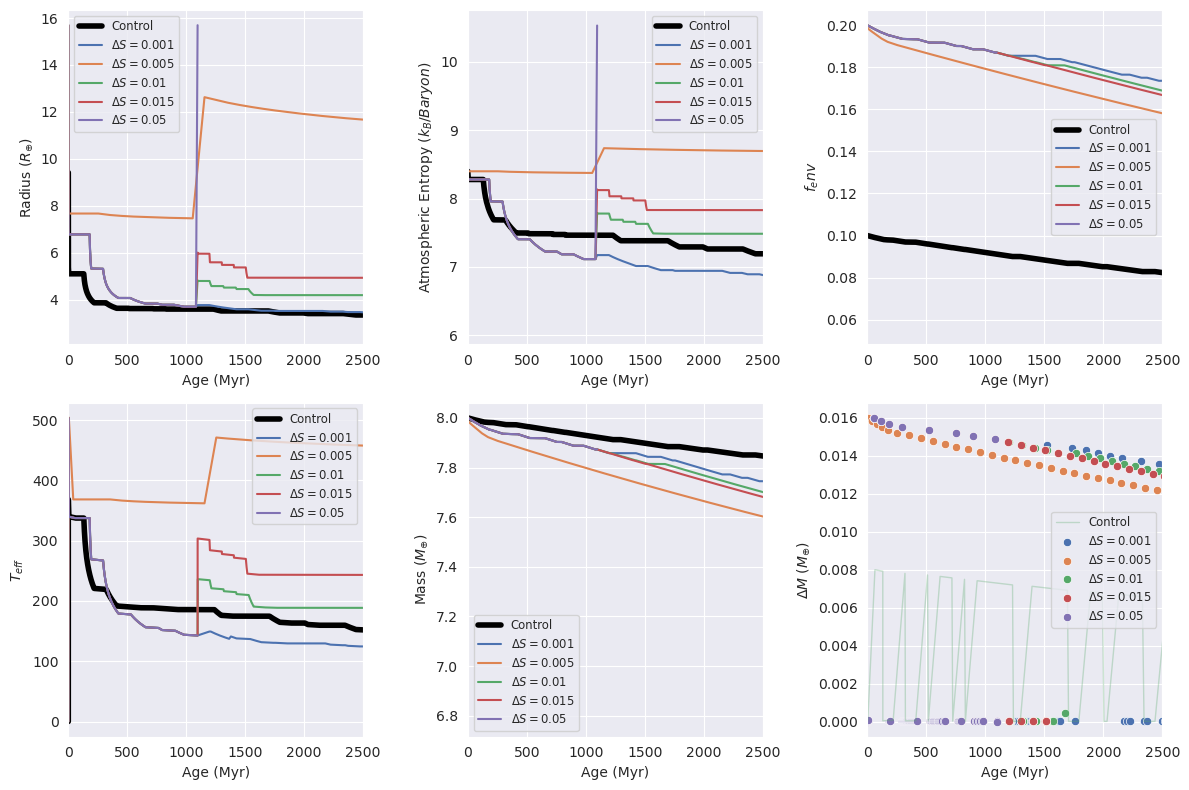

In [12]:
f, axes = plt.subplots(2, 3, figsize=(12, 8))
axs = axes.flatten()

sns.lineplot(data=dfcontrol, x="Age", y="Radius", ax=axs[0], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x='Age', y="Radius", ax=axs[0], label=rf'$\Delta S =${key}')
axs[0].legend(fontsize='small')
axs[0].set_ylabel(r"Radius ($R_{\oplus}$)")

sns.lineplot(data=dfcontrol, x="Age", y="Atmospheric Entropy", ax=axs[1], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="Atmospheric Entropy", ax=axs[1], label=rf'$\Delta S =${key}')
axs[1].legend(fontsize='small')
axs[1].set_ylabel(r"Atmospheric Entropy ($k_B/Baryon$)")

sns.lineplot(data=dfcontrol, x="Age", y="AMF", ax=axs[2], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="AMF", ax=axs[2], label=rf'$\Delta S =${key}')
axs[2].legend(fontsize='small')
axs[2].set_ylabel(r"$f_env$")

sns.lineplot(data=dfcontrol, x="Age", y="T_eff", ax=axs[3], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="T_eff", ax=axs[3], label=rf'$\Delta S =${key}')
axs[3].legend(fontsize='small')
axs[3].set_ylabel(r"$T_{eff}$")

sns.lineplot(data=dfcontrol, x="Age", y="Mass", ax=axs[4], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="Mass", ax=axs[4], label=rf'$\Delta S =${key}')
axs[4].legend(fontsize='small')
axs[4].set_ylabel(r"Mass ($M_{\oplus}$)")

sns.lineplot(data=dfcontrol, x="Age", y="delta_M", ax=axs[5], color='g', alpha=0.3, label='Control', lw=1)
for key, df in evodfs.items():
    sns.scatterplot(data=df, x="Age", y="delta_M", ax=axs[5], label=rf'$\Delta S =${key}')
axs[5].legend(fontsize='small')
axs[5].set_ylabel(r"$\Delta M$ ($M_{\oplus}$)")

for ax in axs:
    ax.set_xlabel('Age (Myr)')
    ax.set_xlim(0,2500)
f.tight_layout()